# 1. Get CIFAR-10

Download from URL

In [ ]:
import torchvision
from torchvision.datasets.utils import download_url
import tarfile
import os

# download dataset saved to current folder
dataset_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
download_url(dataset_url, '.')

# extract tar file
with tarfile.open('./cifar-10-python.tar.gz') as file:
    file.extractall(path='./data')

data_dir = './data/cifar-10-batches-py'
# see what in the folder dataset
print(os.listdir(data_dir))

['test_batch', 'readme.html', 'data_batch_3', 'data_batch_4', 'batches.meta', 'data_batch_2', 'data_batch_5', 'data_batch_1']


Merge all the batches into a single dataset

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)


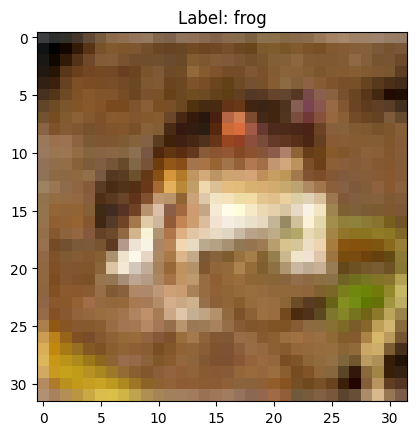

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_batches(batch):
  with open(batch, 'rb') as f:
    dict = pickle.load(f, encoding = 'bytes')
    data = dict[b'data']
    labels = dict[b'labels']
    return data, labels

# combine all training batches
X_train = []
y_train = []

for i in range(1, 6):
  batch = os.path.join(data_dir, f'data_batch_{i}')
  data, labels = load_batches(batch)
  X_train.append(data)
  y_train.append(labels)

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# read test batch
X_test, y_test = load_batches(os.path.join(data_dir, 'test_batch'))
X_test = np.array(X_test)
y_test = np.array(y_test)

# read list of 10 class names
with open(os.path.join(data_dir, 'batches.meta'), 'rb') as f:
  meta = pickle.load(f, encoding='utf-8')
  label_names = meta['label_names']

print(label_names)

# show an example image
images, label = X_train[0], y_train[0]
images = images.reshape(3, 32, 32)
images = images.transpose(1, 2, 0)
plt.title(f'Label: {label_names[label]}')
plt.imshow(images)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# 2. Data preparation

In [ ]:
import torch
from torchvision.transforms import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# reshape images
X_train = X_train.reshape(-1, 3, 32, 32)
X_test = X_test.reshape(-1, 3, 32, 32)

# split validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size = 0.9, random_state = 42)

# normalize data
# define mean and std for CIFAR-10 normalization
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# define training transform
train_transform = transforms.Compose([
  transforms.ToPILImage(),# convert to PIL Image
  transforms.RandomHorizontalFlip(),# randomly flip the image
  transforms.RandomCrop(32, padding=4),# randomly crop a 32x32 patch after padding 4 pixels on each side
  transforms.ToTensor(),# convert the PIL image to tensor and scale pixel values to [0, 1]
  transforms.Normalize(mean, std),# normalize the tensor using the dataset's mean and std
])

# define valid and test transform
test_transform = transforms.Compose([
  transforms.ToPILImage(),# convert to PIL Image
  transforms.ToTensor(),# convert the PIL image to tensor and scale pixel values to [0, 1]
  transforms.Normalize(mean, std),# normalize the tensor using the dataset's mean and std
])

# custom Dataset class
class CIFARDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    img = self.images[idx].transpose(1, 2, 0)  # convert from (C, H, W) to (H, W, C)
    if self.transform:
      img = self.transform(img)
    label = self.labels[idx]
    return img, label

# create Dataset
train_dataset = CIFARDataset(X_train, y_train, transform = train_transform)
val_dataset = CIFARDataset(X_val, y_val, transform = test_transform)
test_dataset = CIFARDataset(X_test, y_test, transform = test_transform)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (45000, 3, 32, 32)
y_train shape: (45000,)
X_val shape: (5000, 3, 32, 32)
y_val shape: (5000,)
X_test shape: (10000, 3, 32, 32)
y_test shape: (10000,)


# 3. Create model, loss function and optimizer

In [ ]:
from torch import nn
import torch.optim as optim

MLP model

In [ ]:
def create_MLP_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # flat data -> 1D
    nn.Flatten(),

    # layer 1
    nn.Linear(3072, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 2
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 3 - output layer
    nn.Linear(256, 10)
  )
  return model

CNN model

In [ ]:
def create_CNN_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # CNN-1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 32 x 16 x 16

    # CNN-2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 64 x 8 x 8

    # CNN-3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 128 x 4 x 4

    nn.Flatten(),

    # Dense layer
    nn.Linear(128*4*4, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

Loss function and optimizer

In [ ]:
MLP_model = create_MLP_model()
CNN_model = create_CNN_model()

criterion = nn.CrossEntropyLoss()
MLP_optimizer = torch.optim.Adam(MLP_model.parameters(), lr = 0.001)
CNN_optimizer = torch.optim.Adam(CNN_model.parameters(), lr = 0.001)

# 4. Training model

In [ ]:
def train_model(model, train_dataset, val_dataset, criterion, optimizer, batch_size = 128, num_epochs = 10):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
  val_loader = DataLoader(val_dataset, batch_size = batch_size * 2, shuffle = False)

  # dict containing 'accuracy', 'val_accuracy', 'loss', 'val_loss' per epoch.
  history = {'train_accuracy': [], 'val_accuracy': [], 'train_loss': [], 'val_loss': []}
  for epoch in range(num_epochs):
    # training loop
    model.train()  # set model to train mode
    train_loss = 0
    train_correct = 0
    train_total = 0

    # loop through batches
    for X_batch, y_batch in train_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # 1. forward pass
      y_pred = model(X_batch)

      # 2. calculate loss
      loss = criterion(y_pred, y_batch)
      train_loss += loss.item()  # accumulate loss

      # 3. optimizer zero grad
      optimizer.zero_grad()

      # 4. backpropagation
      loss.backward()

      # 5. optimizer step
      optimizer.step()

      # calculate accuracy
      preds = torch.argmax(y_pred, dim=1)
      train_correct += (preds == y_batch).sum().item()
      train_total += y_batch.size(0)

    # validation loop
    model.eval()  # set model to eval mode
    val_loss = 0
    val_correct = 0
    val_total = 0

    # no need to calculate gradients
    with torch.inference_mode():
      # loop through batches
      for X_batch, y_batch in val_loader:
        # batch to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # forward pass
        y_pred = model(X_batch)

        # calculate loss
        loss = criterion(y_pred, y_batch)
        val_loss += loss.item()

        # calculate accuracy
        preds = torch.argmax(y_pred, dim=1)
        val_correct += (preds == y_batch).sum().item()
        val_total += y_batch.size(0)

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # print loss and accuracy every epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")
  return history

# 5. Inference

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Evaluate model

In [ ]:
def evaluate_model(model, test_dataset, criterion, batch_size = 128):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  model.eval()  # set model to eval mode
  test_loss = 0
  test_correct = 0
  test_total = 0

  # no need to calculate gradients
  with torch.inference_mode():
    # loop through batches
    for X_batch, y_batch in test_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # forward pass
      y_pred = model(X_batch)

      # calculate loss
      loss = criterion(y_pred, y_batch)
      test_loss += loss.item()

      # calculate accuracy
      preds = torch.argmax(y_pred, dim=1)
      test_correct += (preds == y_batch).sum().item()
      test_total += y_batch.size(0)

  test_loss = test_loss / len(test_loader)
  test_accuracy = test_correct / test_total
  return test_loss, test_accuracy

Plot learning curve

In [ ]:
def plot_curve(history,model_name):
  epochs = range(1, len(history["train_accuracy"]) + 1)

  plt.figure(figsize = (12, 5))

  # accuracy plot
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["train_accuracy"], label = f"Train Accuracy")
  plt.plot(epochs, history["val_accuracy"], label = f"Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.title(f"Accuracy Curve of {model_name}")
  plt.legend()

  # loss plot
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history["train_loss"], label = "Train Loss")
  plt.plot(epochs, history["val_loss"], label = "Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title(f"Loss Curve of {model_name}")
  plt.legend()

  plt.show()

Plot confusion matrix

In [ ]:
def plot_matrix(model,model_name, test_dataset, label_names, batch_size = 128):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  model.eval() # set model to eval mode
  y_true = []
  y_pred = []

  with torch.inference_mode():
    for X_batch, y_batch in test_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # pred X_batch with model
      preds = model(X_batch).argmax(dim = 1)

      # calculate
      y_true.extend(y_batch.cpu().numpy()) # true labels
      y_pred.extend(preds.cpu().numpy()) # predicted labels

  # compute confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # display the confusion matrix using matplotlib
  disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = label_names)
  disp.plot(cmap = plt.cm.Greens)
  plt.title(f"Confusion Matrix of {model_name}")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.xticks(rotation = 45, ha='right')
  plt.tight_layout()
  plt.show()
  return y_true,y_pred

# Compare MLP model and CNN model

Epoch 1/30, Train Loss: 1.8584, Val Loss: 1.6540, Train Accuracy: 0.3242, Val Accuracy: 0.4016
Epoch 2/30, Train Loss: 1.7034, Val Loss: 1.5721, Train Accuracy: 0.3843, Val Accuracy: 0.4184
Epoch 3/30, Train Loss: 1.6456, Val Loss: 1.5221, Train Accuracy: 0.4043, Val Accuracy: 0.4436
Epoch 4/30, Train Loss: 1.6097, Val Loss: 1.4797, Train Accuracy: 0.4201, Val Accuracy: 0.4556
Epoch 5/30, Train Loss: 1.5776, Val Loss: 1.4525, Train Accuracy: 0.4271, Val Accuracy: 0.4700
Epoch 6/30, Train Loss: 1.5559, Val Loss: 1.4238, Train Accuracy: 0.4393, Val Accuracy: 0.4816
Epoch 7/30, Train Loss: 1.5336, Val Loss: 1.4085, Train Accuracy: 0.4473, Val Accuracy: 0.4820
Epoch 8/30, Train Loss: 1.5214, Val Loss: 1.3870, Train Accuracy: 0.4491, Val Accuracy: 0.4984
Epoch 9/30, Train Loss: 1.5085, Val Loss: 1.3799, Train Accuracy: 0.4567, Val Accuracy: 0.5000
Epoch 10/30, Train Loss: 1.4953, Val Loss: 1.3617, Train Accuracy: 0.4602, Val Accuracy: 0.5050
Epoch 11/30, Train Loss: 1.4823, Val Loss: 1.3582

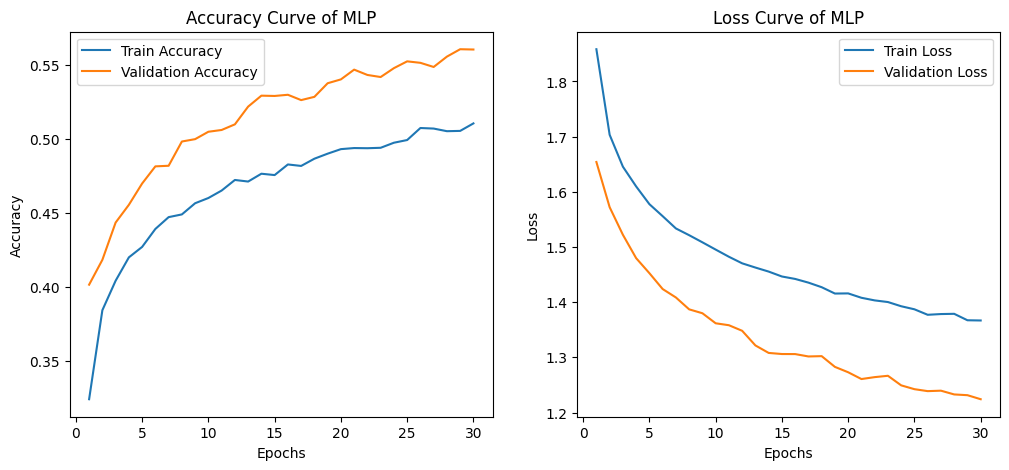

Test Loss: 1.2192, Test Accuracy: 0.5620


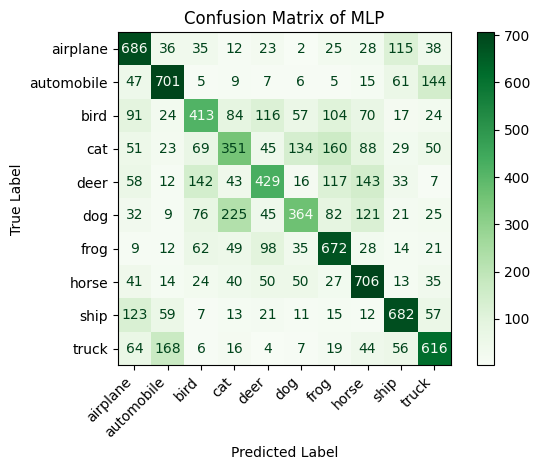


MLP Classification Report:
              precision    recall  f1-score   support

    airplane       0.57      0.69      0.62      1000
  automobile       0.66      0.70      0.68      1000
        bird       0.49      0.41      0.45      1000
         cat       0.42      0.35      0.38      1000
        deer       0.51      0.43      0.47      1000
         dog       0.53      0.36      0.43      1000
        frog       0.55      0.67      0.60      1000
       horse       0.56      0.71      0.63      1000
        ship       0.66      0.68      0.67      1000
       truck       0.61      0.62      0.61      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.55     10000
weighted avg       0.56      0.56      0.55     10000

MLP Macro Precision: 0.5560
MLP Macro Recall: 0.5620
MLP Macro F1-score: 0.5543


In [ ]:
history = train_model(MLP_model, train_dataset, val_dataset, criterion, MLP_optimizer, batch_size = 128, num_epochs = 30)
plot_curve(history,"MLP")
test_loss, test_acc = evaluate_model(MLP_model, test_dataset, criterion, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
y_true_mlp, y_pred_mlp = plot_matrix(MLP_model,"MLP", test_dataset, label_names) # Get true and predicted labels

print("\nMLP Classification Report:")
report_dict_mlp = classification_report(y_true_mlp, y_pred_mlp, target_names=label_names, output_dict=True)
print(classification_report(y_true_mlp, y_pred_mlp, target_names=label_names))

macro_precision_mlp = report_dict_mlp['macro avg']['precision']
macro_recall_mlp = report_dict_mlp['macro avg']['recall']
macro_f1_mlp = report_dict_mlp['macro avg']['f1-score']

print(f"MLP Macro Precision: {macro_precision_mlp:.4f}")
print(f"MLP Macro Recall: {macro_recall_mlp:.4f}")
print(f"MLP Macro F1-score: {macro_f1_mlp:.4f}")

torch.save(MLP_model.state_dict(), 'MLP_model.pth')

Epoch 1/20, Train Loss: 1.5939, Val Loss: 1.3365, Train Accuracy: 0.4073, Val Accuracy: 0.5098
Epoch 2/20, Train Loss: 1.1941, Val Loss: 0.9744, Train Accuracy: 0.5678, Val Accuracy: 0.6370
Epoch 3/20, Train Loss: 1.0117, Val Loss: 0.8596, Train Accuracy: 0.6400, Val Accuracy: 0.6896
Epoch 4/20, Train Loss: 0.8918, Val Loss: 0.7628, Train Accuracy: 0.6880, Val Accuracy: 0.7264
Epoch 5/20, Train Loss: 0.8131, Val Loss: 0.7355, Train Accuracy: 0.7170, Val Accuracy: 0.7496
Epoch 6/20, Train Loss: 0.7594, Val Loss: 0.6971, Train Accuracy: 0.7343, Val Accuracy: 0.7512
Epoch 7/20, Train Loss: 0.7099, Val Loss: 0.6120, Train Accuracy: 0.7523, Val Accuracy: 0.7842
Epoch 8/20, Train Loss: 0.6772, Val Loss: 0.6388, Train Accuracy: 0.7640, Val Accuracy: 0.7764
Epoch 9/20, Train Loss: 0.6392, Val Loss: 0.6072, Train Accuracy: 0.7761, Val Accuracy: 0.7896
Epoch 10/20, Train Loss: 0.6127, Val Loss: 0.6019, Train Accuracy: 0.7856, Val Accuracy: 0.7972
Epoch 11/20, Train Loss: 0.5889, Val Loss: 0.5899

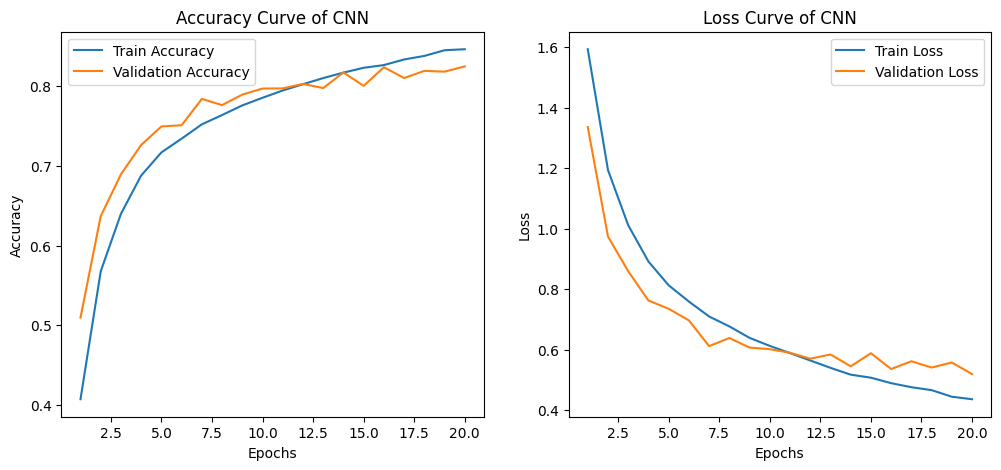

Test Loss: 0.5723, Test Accuracy: 0.8068


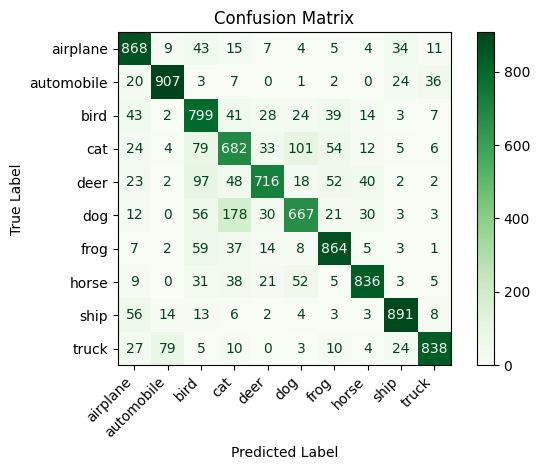


CNN Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.87      0.83      1000
  automobile       0.89      0.91      0.90      1000
        bird       0.67      0.80      0.73      1000
         cat       0.64      0.68      0.66      1000
        deer       0.84      0.72      0.77      1000
         dog       0.76      0.67      0.71      1000
        frog       0.82      0.86      0.84      1000
       horse       0.88      0.84      0.86      1000
        ship       0.90      0.89      0.89      1000
       truck       0.91      0.84      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

CNN Macro Precision: 0.8114
CNN Macro Recall: 0.8068
CNN Macro F1-score: 0.8073


In [ ]:
history = train_model(CNN_model, train_dataset, val_dataset, criterion, CNN_optimizer, batch_size = 128, num_epochs = 20)
plot_curve(history,"CNN")
test_loss, test_acc = evaluate_model(CNN_model, test_dataset, criterion, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
y_true_cnn, y_pred_cnn = plot_matrix(CNN_model,"CNN", test_dataset, label_names) # Get true and predicted labels

print("\nCNN Classification Report:")
report_dict_cnn = classification_report(y_true_cnn, y_pred_cnn, target_names=label_names, output_dict=True)
print(classification_report(y_true_cnn, y_pred_cnn, target_names=label_names))

macro_precision_cnn = report_dict_cnn['macro avg']['precision']
macro_recall_cnn = report_dict_cnn['macro avg']['recall']
macro_f1_cnn = report_dict_cnn['macro avg']['f1-score']

print(f"CNN Macro Precision: {macro_precision_cnn:.4f}")
print(f"CNN Macro Recall: {macro_recall_cnn:.4f}")
print(f"CNN Macro F1-score: {macro_f1_cnn:.4f}")


torch.save(CNN_model.state_dict(), 'CNN_model.pth')